In [121]:
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [122]:
data  = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=42)

In [123]:
X = data[0]
y = data[1]
# print(f"y is {[y==0]}")

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [125]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(f"coefficients: {model.coef_}, intercept: {model.intercept_}")

Accuracy: 0.95
coefficients: [[ 3.06127461 -0.68478105]], intercept: [0.23246397]


In [ ]:
import numpy as np

class perceptron:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.weights = None
        self.intercept = None

    def fit(self, X_train, y_train):
        self.weights = np.zeros(X_train.shape[1])
        self.intercept = 0
        
        for i in range(self.n_iter):
            idx = i % X_train.shape[0]   # to stay within training data range
            
            data_point = X_train[idx]
            y_actual = y_train[idx]

            y_predicted = np.dot(data_point, self.weights) + self.intercept

            if y_predicted >= 0:
                y_predicted = 1
            else:
                y_predicted = 0

            error = y_actual - y_predicted

            if error != 0:
                self.weights += self.learning_rate * error * data_point
                self.intercept += self.learning_rate * error

    def predict(self, X_test):
        y_predicted = np.dot(X_test, self.weights) + self.intercept
        y_predicted[y_predicted >= 0] = 1
        y_predicted[y_predicted < 0] = 0
        return y_predicted

In [127]:

new_model = perceptron(learning_rate=0.01, n_iter=1000)
new_model.fit(X_train, y_train)
y_pred_new = new_model.predict(X_test)
accuracy_new = accuracy_score(y_test, y_pred_new)
print("Accuracy of custom perceptron model:", accuracy_new*100)

Accuracy of custom perceptron model: 100.0


In [128]:
print(f"coefficients: {new_model.weights}, intercept: {new_model.intercept}")

coefficients: [ 0.05247561 -0.01670351], intercept: 0.0


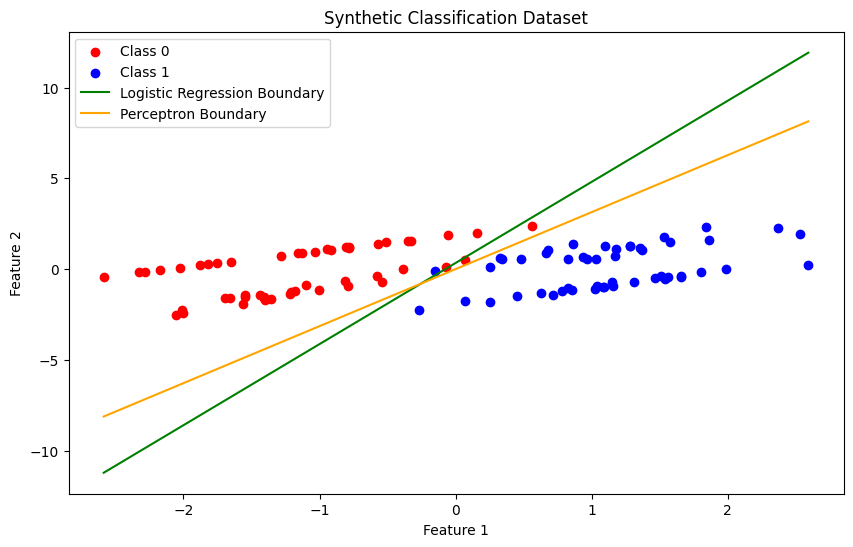

In [129]:
plt.figure(figsize=(10, 6))

# scatter points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

# logistic regression decision boundary
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = -(model.coef_[0][0] * x1 + model.intercept_[0]) / model.coef_[0][1]
plt.plot(x1, x2, color='green', label='Logistic Regression Boundary')

# perceptron decision boundary
x2_perceptron = -(new_model.weights[0] * x1 + new_model.intercept) / new_model.weights[1]
plt.plot(x1, x2_perceptron, color='orange', label='Perceptron Boundary')

plt.title('Synthetic Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [135]:
import numpy as np

class perceptron_with_sigmoid:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.weights = None
        self.intercept = None

    def fit(self, X_train, y_train):
        self.weights = np.zeros(X_train.shape[1])
        self.intercept = 0
        
        for i in range(self.n_iter):
            idx = i % X_train.shape[0]   
            
            data_point = X_train[idx]
            y_actual = y_train[idx]

            z = np.dot(data_point, self.weights) + self.intercept
            y_predicted = 1 / (1 + np.exp(-z))

            error = y_actual - y_predicted

            self.weights += self.learning_rate * error * data_point
            self.intercept += self.learning_rate * error

    def predict(self, X_test):
        z = np.dot(X_test, self.weights) + self.intercept
        y_predicted = 1 / (1 + np.exp(-z))
        return np.where(y_predicted >= 0.5, 1, 0)

In [136]:
perceptron_with_sigmoid_model = perceptron_with_sigmoid(learning_rate=0.01, n_iter=1000)
perceptron_with_sigmoid_model.fit(X_train, y_train)
y_pred_perceptron_with_sigmoid = perceptron_with_sigmoid_model.predict(X_test)
accuracy_perceptron_with_sigmoid = accuracy_score(y_test, y_pred_perceptron_with_sigmoid)
print(f"Coefficients: {perceptron_with_sigmoid_model.weights}, Intercept: {perceptron_with_sigmoid_model.intercept}")
print("Accuracy of perceptron with sigmoid model:", accuracy_perceptron_with_sigmoid*100)

Coefficients: [ 1.97153025 -0.30733194], Intercept: 0.11424066540524264
Accuracy of perceptron with sigmoid model: 95.0


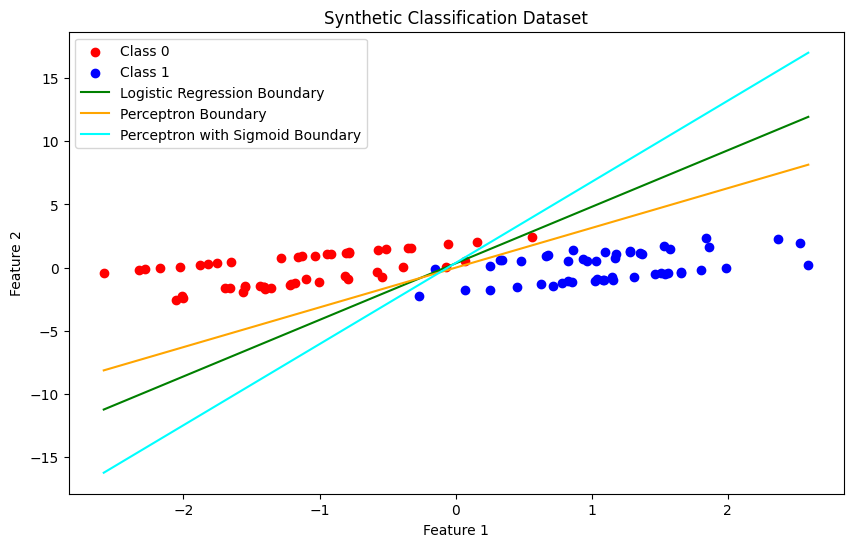

In [132]:
plt.figure(figsize=(10, 6))

# scatter points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

# logistic regression decision boundary
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = -(model.coef_[0][0] * x1 + model.intercept_[0]) / model.coef_[0][1]
plt.plot(x1, x2, color='green', label='Logistic Regression Boundary')

# perceptron decision boundary
x2_perceptron = -(new_model.weights[0] * x1 + new_model.intercept) / new_model.weights[1]
plt.plot(x1, x2_perceptron, color='orange', label='Perceptron Boundary')

# perceptron with sigmoid decision boundary
x2_perceptron_sigmoid = -(perceptron_with_sigmoid_model.weights[0] * x1 + perceptron_with_sigmoid_model.intercept) / perceptron_with_sigmoid_model.weights[1]
plt.plot(x1, x2_perceptron_sigmoid, color='cyan', label='Perceptron with Sigmoid Boundary')

plt.title('Synthetic Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()